In [19]:
%matplotlib widget

In [20]:
import numpy as np
import pygimli as pg
import emg3d 
import empymod as ep
import sys
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
import math
from joblib import Parallel, delayed

from matplotlib.colors import LogNorm
L = LogNorm(vmin=1e-4, vmax=.1)
popts = {'norm': L}

sys.path.insert(1, '../src')

from showStitched import showStitchedModels


In [21]:
# Import model just one section

model = np.load('models/model_sinusodial.npy')
geom = np.load('data/geom_sinusoidal.npy')
data = np.load('../Sinusoidal/data_3D_Sinusoidal_topo_sorted.npy')
midp_x = np.load('../Sinusoidal/midp_x_data_Sinu_topo.npy')
topo = np.load('models/topo_sinusoidal.npy')

In [22]:
# Forward function

def FDEM3D_topo(geom, model_sig, model_air, height = 0.25):
    """ Simulate Dualem842S in 3D """
    startTime = time.time()
    
    frequency = 9000 # Hertz

    src_x   = geom[0]
    src_z   = geom[1]
    src_y   = geom[2]
    rec2_x  = geom[3]
    rec2_z  = geom[4]
    rec21_x = geom[5]
    rec21_z = geom[6]
    rec4_x  = geom[7]
    rec4_z  = geom[8]
    rec41_x = geom[9]
    rec41_z = geom[10]
    rec8_x  = geom[11]
    rec8_z  = geom[12]
    rec81_x = geom[13]
    rec81_z = geom[14]
    alpha   = geom[15]    
    
    # Define sources geometry
    # source = [x, y, z, azimuth, dip]
    Hsource_coords = [src_x, src_y, src_z, 0, 90 + math.degrees(alpha)]
    Vsource_coords = [src_x, src_y, src_z, 90, 0 + math.degrees(alpha)]
   # Psource_coords = Hsource_coords
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsource_coords)
    Vsource = emg3d.TxMagneticPoint(Vsource_coords)
   # Psource = emg3d.TxMagneticPoint(Psource_coords)

    # Define receivers
    Hrec2 = [rec2_x, src_y, rec2_z, 0, 90 + math.degrees(alpha)]
    Vrec2 = [rec2_x, src_y, rec2_z, 90, 0 + math.degrees(alpha)]
    Prec2 = [rec21_x, src_y, rec21_z, 0, 0 + math.degrees(alpha)]
    Prec2_p = [rec21_x, src_y, rec21_z, 0, 90 + math.degrees(alpha)]

    Hrec4 = [rec4_x, src_y, rec4_z, 0, 90 + math.degrees(alpha)]
    Vrec4 = [rec4_x, src_y, rec4_z, 90, 0 + math.degrees(alpha)]
    Prec4 = [rec41_x, src_y, rec41_z, 0, 0 + math.degrees(alpha)]
    Prec4_p = [rec41_x, src_y, rec41_z, 0, 90 + math.degrees(alpha)]

    Hrec8 = [rec8_x, src_y, rec8_z, 0, 90 + math.degrees(alpha)]
    Vrec8 = [rec8_x, src_y, rec8_z, 90, 0 + math.degrees(alpha)]
    Prec8 = [rec81_x, src_y, rec81_z, 0, 0 + math.degrees(alpha)]
    Prec8_p = [rec81_x, src_y, rec81_z, 0, 90 + math.degrees(alpha)]

   # print('Hsource:', Hsource_coords)
   # print('Vsource:', Vsource_coords)
   # print('Hrec2:', Hrec2)
   # print('Vrec2:', Vrec2)
   # print('Prec2:', Prec2)
   # print('Prec2_p:', Prec2_p)
   # print('Hrec4:', Hrec4)
   # print('Vrec4:', Vrec4)
   # print('Prec4:', Prec4)
   # print('Prec4_p:', Prec4_p)
   # print('Hrec8:', Hrec8)
   # print('Vrec8:', Vrec8)
   # print('Prec8:', Prec8)
   # print('Prec8_p:', Prec8_p)
    
    # Solve Electrical fields
    print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = model_sig, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = model_sig, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = model_air, source = Vsource, frequency = frequency)
    
    # Get magnetic fields
    print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = model_sig, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = model_sig, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = model_air, efield = Efield_V_p)
    
    # Get fields at receivers
    print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec2 = Hfield_H.get_receiver(Hrec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec2_p = Hfield_H_p.get_receiver(Hrec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec2_s = H_Hrec2 - H_Hrec2_p

    # For total field Hsource
    H_Hrec4 = Hfield_H.get_receiver(Hrec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec4_p = Hfield_H_p.get_receiver(Hrec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec4_s = H_Hrec4 - H_Hrec4_p

    # For total field Hsource
    H_Hrec8 = Hfield_H.get_receiver(Hrec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec8_p = Hfield_H_p.get_receiver(Hrec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec8_s = H_Hrec8 - H_Hrec8_p
    
    # For total field Vsource
    H_Vrec2 = Hfield_V.get_receiver(Vrec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec2_p = Hfield_V_p.get_receiver(Vrec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec2_s = H_Vrec2 - H_Vrec2_p

    # For total field Vsource
    H_Vrec4 = Hfield_V.get_receiver(Vrec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec4_p = Hfield_V_p.get_receiver(Vrec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec4_s = H_Vrec4 - H_Vrec4_p

    # For total field Vsource
    H_Vrec8 = Hfield_V.get_receiver(Vrec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec8_p = Hfield_V_p.get_receiver(Vrec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec8_s = H_Vrec8 - H_Vrec8_p
    
    # For total field Psource
    H_Prec2 = Hfield_H.get_receiver(Prec2)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec2_p_xz = Hfield_H_p.get_receiver(Prec2)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec2_s = H_Prec2 - H_Prec2_p_xz
    # Primary field Psource in zz direction
    H_Prec2_p = Hfield_H_p.get_receiver(Prec2_p)*(2j * np.pi * frequency * mu_0) 

    # For total field Psource
    H_Prec4 = Hfield_H.get_receiver(Prec4)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec4_p_xz = Hfield_H_p.get_receiver(Prec4)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec4_s = H_Prec4 - H_Prec4_p_xz
    # Primary field Psource in zz direction
    H_Prec4_p = Hfield_H_p.get_receiver(Prec4_p)*(2j * np.pi * frequency * mu_0) 

    # For total field Psource
    H_Prec8 = Hfield_H.get_receiver(Prec8)*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec8_p_xz = Hfield_H_p.get_receiver(Prec8)*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec8_s = H_Prec8 - H_Prec8_p_xz
    # Primary field Psource in zz direction
    H_Prec8_p = Hfield_H_p.get_receiver(Prec8_p)*(2j * np.pi * frequency * mu_0) 
    
    # Calculate output components OP and IP
    print('getting output components')
    #OUT = []
    # Horizontal coplanar
    op_h2 = (H_Hrec2_s/H_Hrec2_p).imag.amp()
    ip_h2 = (H_Hrec2_s/H_Hrec2_p).real.amp()

    op_h4 = (H_Hrec4_s/H_Hrec4_p).imag.amp()
    ip_h4 = (H_Hrec4_s/H_Hrec4_p).real.amp()

    op_h8 = (H_Hrec8_s/H_Hrec8_p).imag.amp()
    ip_h8 = (H_Hrec8_s/H_Hrec8_p).real.amp()

    # Vertical coplanar
    op_v2 = (H_Vrec2_s/H_Vrec2_p).imag.amp()
    ip_v2 = (H_Vrec2_s/H_Vrec2_p).real.amp()

    op_v4 = (H_Vrec4_s/H_Vrec4_p).imag.amp()
    ip_v4 = (H_Vrec4_s/H_Vrec4_p).real.amp()

    op_v8 = (H_Vrec8_s/H_Vrec8_p).imag.amp()
    ip_v8 = (H_Vrec8_s/H_Vrec8_p).real.amp()
    
    # Perpendicular
    op_p2 = (H_Prec2_s/H_Prec2_p).imag.amp()
    ip_p2 = (H_Prec2_s/H_Prec2_p).real.amp()

    op_p4 = (H_Prec4_s/H_Prec4_p).imag.amp()
    ip_p4 = (H_Prec4_s/H_Prec4_p).real.amp()

    op_p8 = (H_Prec8_s/H_Prec8_p).imag.amp()
    ip_p8 = (H_Prec8_s/H_Prec8_p).real.amp()

    # src x pos | rec x pos | midpoint | data
  #  OUT = {'geom' : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
  #         'src_x' : np.ones(9)*src_x,
  #         'src_y' : np.ones(9)*src_y,
  #         'rec_x' : np.hstack((rec2_x, rec4_x, rec8_x, 
  #                              rec2_x, rec4_x, rec8_x, 
  #                              rec21_x, rec41_x, rec81_x)),
  #         'midpx' : np.hstack(( src_x + 1, src_x + 2, src_x + 4,
  #                               src_x + 1, src_x + 2, src_x + 4,
  #                               src_x + 1.05, src_x + 2.05, src_x + 4.05 )),
  #         'op' : np.hstack((op_h2, op_h4, op_h8, op_v2, op_v4, op_v8, op_p2, op_p4, op_p8)),
  #         'ip' : np.hstack((ip_h2, ip_h4, ip_h8, ip_v2, ip_v4, ip_v8, ip_p2, ip_p4, ip_p8)) 
  #        }

  #  OUT = pd.DataFrame(OUT)
  #  print(OUT)
               
    endTime = time.time()
    print('Done in', (endTime - startTime), 'seconds!')

    data = np.hstack((op_h2, op_h4, op_h8, op_v2, op_v4, op_v8, op_p2, op_p4, op_p8,
                      ip_h2, ip_h4, ip_h8, ip_v2, ip_v4, ip_v8, ip_p2, ip_p4, ip_p8))
    return data

class CustomError(Exception):
    """Custom exception for specific error handling."""
    def __init__(self, message):
        self.message = message
        super().__init__(self.message)

def FDEM25D_line_topo(sigmas, thick, topo, geom, pos, frequency=9000,):

    # topo -> array of topography for the positions
    # pos -> array of positions

 #   if (geom[1] < topo):
 #       raise CustomError("wrong geometry src_z")
        
 #   if (geom[4] < topo):
 #       raise CustomError("wrong geometry rec2_z")
    
 #   if (geom[6] < topo):
 #       raise CustomError("wrong geometry rec21_z")
    
 #   if (geom[8] < topo):
 #       raise CustomError("wrong geometry rec4_z")
    
 #   if (geom[10] < topo):
 #       raise CustomError("wrong geometry rec41_z")

 #   if (geom[12] < topo):
 #       raise CustomError("wrong geometry rec8_z")

 #   if (geom[14] < topo):
 #       raise CustomError("wrong geometry rec81_z")

    src_x = geom[0]
    src_z = geom[1]
    
    sig_bg = 20/1000
    sig_air = 1/1e6
    
    # Define mesh
    mesh = emg3d.construct_mesh(frequency = frequency,
                             properties = [sig_air, sig_air, sig_bg, sig_air],
                             center = [src_x+.025, 0.025, src_z+.025],
                             mapping='Conductivity',
                             domain = ([src_x - 10, src_x + 10], [-10, 10], [src_z-3, src_z+3]),
                             min_width_limits = [0.2, 0.2, 0.05], # changed z from 0.1 to 0.2
                             center_on_edge=True,
                             stretching= {'x': [1.1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                             lambda_from_center=True,
                             lambda_factor=3, 
                       #      cell_numbers=[512, 128, 128]
                       #      max_buffer = 300000,
                       #      min_width_pps = 5
                             )
    
    print('src x:', src_x)
    print('src z:', src_z)
    #print('rec x:', [rec2_x, rec21_x, rec4_x, rec41_x, rec8_x, rec81_x])
    #print('rec z:', [rec2_z, rec4_z, rec8_z])
    #print('alpha:', math.degrees(alpha))
    print(mesh)

    # Define air layer
    sig_x = np.ones(mesh.n_cells)*sig_air # empty array to be populated
    sig_air = np.ones(mesh.n_cells)*sig_air # air array
    
    # Fill before position 

    depths = np.array([topo[pos[0]],  topo[pos[-1]]-thick[0]])
    
    x = mesh.cell_centers[:,0] <= pos[0]
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[0]) & (mesh.cell_centers[:,2] > depths[1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[1]) 
    
    sig_x[x*y*z_lay1] = sigmas[0] # First layer sigma
    sig_x[x*y*z_lay2] = sigmas[1] # Second layer sigma
    
    for p in pos:

        depths = np.array([topo[p],  topo[pos[-1]]-thick[0]])
       
        x = (mesh.cell_centers[:,0] >= p) & (mesh.cell_centers[:,0] < p+1)
        y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
        z_lay1 = (mesh.cell_centers[:,2] < depths[0]) & (mesh.cell_centers[:,2] > depths[1])
        z_lay2 = (mesh.cell_centers[:,2] < depths[1]) 
    
        sig_x[x*y*z_lay1] = sigmas[0]
        sig_x[x*y*z_lay2] = sigmas[1]
    
    # fill after position npos

    depths = np.array([topo[pos[-1]],  topo[pos[-1]]-thick[0]])
    
    x = (mesh.cell_centers[:,0] > pos[-1]+1) 
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool)
    z_lay1 = (mesh.cell_centers[:,2] < depths[0]) & (mesh.cell_centers[:,2] > depths[1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[1]) 
    
    sig_x[x*y*z_lay1] = sigmas[0]
    sig_x[x*y*z_lay2] = sigmas[1]
    
    
    #  4. Define models
    
    Model = emg3d.Model(mesh, 
                     property_x = sig_x,
                     mapping = 'Conductivity')
    
    Model_air = emg3d.Model(mesh,
                         property_x = sig_air,
                         mapping = 'Conductivity')

    data_3D = FDEM3D_topo(geom, 
                              Model, 
                              Model_air)

    return data_3D, mesh, Model

In [23]:
class FDEM25DModelling(pg.frameworks.Modelling):
    
    def __init__(self, nlay, topo, geom, pos):
        self.nlay = nlay
        self.topo = topo
        self.geom = geom
        self.pos =  pos
        Mesh = pg.meshtools.createMesh1DBlock(nlay)
        super().__init__()
        self.setMesh(Mesh)
        print('Initialized')
                   
    def response(self, par):
        """ Compute response vector for a certain model [mod] 
        par = [thickness_1, thickness_2, ..., thickness_n, sigma_1, sigma_2, ..., sigma_n]
        """
        print('sigma:', np.asarray(par)[self.nlay-1:self.nlay*2-1])
        print('thicks:', np.asarray(par)[:self.nlay-1])
        resp = FDEM25D_line_topo(sigmas = np.asarray(par)[self.nlay-1:self.nlay*2-1],   # sigma in Siemens *10
                                 thick = np.asarray(par)[:self.nlay-1],                  # thickness
                                 topo = self.topo,
                                 geom = self.geom,
                                 pos = self.pos,
                      )
        return resp
    
    def response_mt(self, par, i=0):
        """Multi-threaded forward response."""
        return self.response(par)
    
 #   def createJacobian(self, par, dx=0.05):
 #       """ compute Jacobian for a 1D model """
 #       resp = self.response(par)
 #       n_rows = len(resp) # number of data values in data vector
 #       n_cols = len(par) # number of model parameters
 #       J = self.jacobian() # we define first this as the jacobian
 #       J.resize(n_rows, n_cols)
 #       Jt = np.zeros((n_cols, n_rows))
 #       for j in range(n_cols):
 #           mod_plus_dx = par.copy()
 #           mod_plus_dx[j] += dx
 #           Jt[j,:] = (self.response(mod_plus_dx) - resp)/dx # J.T in col j
 #       for i in range(n_rows):
 #           J[i] = Jt[:,i]


# Test a halfspace

In [24]:
n1 = 100
n2 = 140
pos = np.arange(n1,n2)


In [25]:
thick = [model[n1+4,0]]
sigmas = model[n1+4,1:]
geom_ = geom[n1+4]
topo_ = topo.copy() #np.ones_like(pos)*-1


data_25D, mesh, Model = FDEM25D_line_topo(sigmas, thick, topo_, geom_, pos)

src x: 99.99829192699634
src z: -0.4209418289683435

  TensorMesh: 1,769,472 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     96   -101,154.87    101,354.91      0.20 33,749.10    1.50
   y     96   -101,254.87    101,254.92      0.20 33,749.10    1.50
   z    192       -745.96    135,926.33      0.05 35,875.83    1.36


Solving sources...


KeyboardInterrupt: 

In [ ]:
mesh.plot_3d_slicer(
    Model.property_x, xslice=10, yslice=10, zslice = -1, pcolor_opts=popts, xlim=[n1-10,n2+40], ylim=[-10,10], zlim=[-4,2], 
)



In [ ]:
c = mesh.plot_slice(
    Model.property_x, pcolor_opts=popts, grid=True, range_x=[n1-10,n2+10], range_y=[-3,0], v_type='CC',
                     normal='Y',
)
#fig.colorbar(c[0])

In [33]:
# Compare with empymod data

In [68]:
def FDEM1D(sgm, thk, height=0.25, ):
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]
                
    norm : normalize values with respect to offset

    Returns
    -------
    Array [OP, IP]

    """  
    # Set geometry
    Freq = 9000
    coilSpacing = [2, 4, 8]
    pcoilSpacing = [2.1, 4.1, 8.1]
    coilOrient = np.array(['H', 'V', 'P'])
    #height = 0

    # Source and receivers geometry [x, y, z]
    source    = [0, 0, -height]
    receivers = [coilSpacing, np.zeros(len(coilSpacing)), -height]    
    preceivers = [pcoilSpacing, np.zeros(len(pcoilSpacing)), -height]

    # Depth and resistivity
    res_air = 1e6
    res = np.hstack((res_air, 1/sgm))
    depth = np.hstack((0, np.cumsum(thk)))
    # Empty array to store responses
    HOP = []
    HIP = []
    POP = []
    PIP = []
    VOP = []
    VIP = []
    
    if any(coilOrient == 'H'):

        H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                          verb=0)*(2j * np.pi * Freq * mu_0) 
        H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                         ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp()# * norm
        ip = (H_Hs/H_Hp).real.amp()# * norm
        HOP.append(op) 
        HIP.append(ip)

    if any(coilOrient == 'P'):
        # Maybe put 0.1m in receiver offset
        P_Hs = ep.dipole(source, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = ep.dipole(source, preceivers, depth=[], res=[res_air], freqtime= Freq,
                         ab=66, verb=0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp()# * norm
        ip = (P_Hs/P_Hp).real.amp()# * norm
        POP.append(op)
        PIP.append(ip)
        
    if any(coilOrient == 'V'):
        V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                         ab=55, verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp()# * norm
        ip = (V_Hs/V_Hp).real.amp()# * norm
        VOP.append(op)
        VIP.append(ip)

    return np.array([HOP, VOP, POP, HIP, VIP, PIP]).ravel() 

In [69]:
data_1D = FDEM1D(np.array(sigmas), thick)

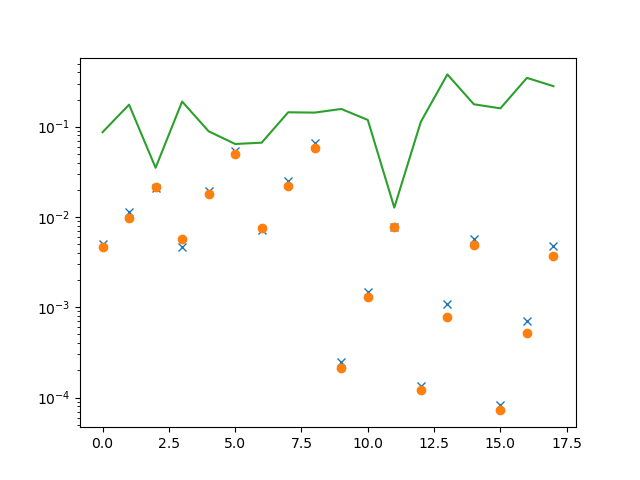

In [58]:
fig, ax = plt.subplots()

ax.plot(data_25D, 'x')
ax.plot(data_1D, 'o')
ax.semilogy(np.abs(data_25D-data_1D)/data_1D)

In [59]:
data_25D

array([4.99775958e-03, 1.14182768e-02, 2.08454114e-02, 4.62832697e-03,
       1.96191680e-02, 5.33387049e-02, 7.11049588e-03, 2.52911186e-02,
       6.64423191e-02, 2.45467494e-04, 1.47015027e-03, 7.65130644e-03,
       1.33264736e-04, 1.08605152e-03, 5.73481930e-03, 8.35427372e-05,
       7.05752991e-04, 4.71701191e-03])

In [60]:
data_1D

array([4.59803563e-03, 9.71538134e-03, 2.16028774e-02, 5.71336374e-03,
       1.80168670e-02, 5.01150303e-02, 7.61719750e-03, 2.20997281e-02,
       5.81173687e-02, 2.12132053e-04, 1.31406481e-03, 7.74973229e-03,
       1.19706381e-04, 7.87311795e-04, 4.87202349e-03, 7.20453090e-05,
       5.23908036e-04, 3.68193898e-03])

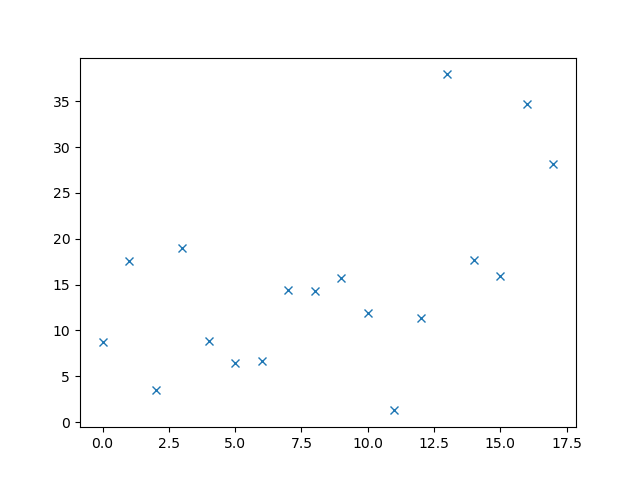

In [61]:
fig, ax = plt.subplots()

ax.plot((np.abs((data_25D-data_1D)/data_1D))*100, 'x')

# Now test the inversion!

In [71]:
nlay = np.shape(model)[1] - 1

#nsrcx = 4
#nmdpx = nsrcx + 4

fop = FDEM25DModelling(nlay=nlay, topo = topo_, geom=geom_, pos=pos)

transThk = pg.trans.TransLogLU(0.1,3)
transSig = pg.trans.TransLogLU(10/1000,300/1000) # siemens *100
#transData = pg.trans.TransLog()

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)

# Perform inversion in each position

startModel = np.array([1.5, 0.1, 0.1]) # initial model CHANGE SCALES

model_inv = []
response = []

Initialized


In [72]:
data_p = data_1D

rel_err = np.ones_like(data_p)*1e-1
inv = pg.Inversion(fop)
#inv._stopAtChi1=True
model_inv.append(inv.run(dataVals=data_p, errorVals=rel_err, startModel=startModel, verbose=True, lam=0, ))
response.append(inv.response)

19/02/25 - 14:55:35 - pyGIMLi - INFO - Starting inversion.


Calculating Jacobian matrix (forced=1)...Create Jacobian matrix (brute force) ...min/max(dweight) = 172.066/138802
fop: <__main__.FDEM25DModelling object at 0x7f81cdec45e0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x7f81c88fbca0>
Model transformation (cumulative):
	 0 <pgcore._pygimli_.RTransLogLU object at 0x7f81cdec6e80>
	 1 <pgcore._pygimli_.RTransLogLU object at 0x7f81cdec5e40>
min/max (data): 7.2e-05/0.06
min/max (error): 10%/10%
min/max (start model): 0.1/1.5
--------------------------------------------------------------------------------
sigma: [0.1 0.1]
thicks: [1.5]
use model trans from RegionManager
src x: 99.99829192699634
src z: -0.4209418289683435

  TensorMesh: 1,769,472 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     96   -101,154.87    101,354.91      0.20 33,749.10    1.50
   y     9


KeyboardInterrupt



In [ ]:
print('model true:', [thick[0], sigmas[0]*100, sigmas[1]*100])

In [ ]:
print('model inv:', model_inv)

In [ ]:
fig, ax = plt.subplots()

model_true =  [thick[0], sigmas[0]*100, sigmas[1]*100]
ax.step([model_true[1],  model_true[-1], model_true[-1]], [0,-model_true[0],-3], label='True')
ax.step([startModel[1], startModel[-1], startModel[-1]], [0,-startModel[0],-3], label='Initial')
ax.step([model_inv[0][1],  model_inv[0][-1], model_inv[0][-1]], [0,-model_inv[0][0],-3], label='Inverted')
ax.set_xscale('log')
ax.legend()
ax.set_ylabel('Depth')
ax.set_xlabel('EC mS/m')

In [ ]:
fig, ax = plt.subplots()

data_inv = np.array(response[0])
ax.plot(data_p,'.')
ax.plot(data_inv, 'x')
ax.set_title('Data Fit')


In [ ]:
fig, ax = plt.subplots()
ax.plot(np.abs((data_p - data_inv)/data_p)*100,'.')

